In [1]:
import xarray as xr

In [2]:
filename = '/home/lacrio/Documents/thermo_eq_test_lev/era5_T2_202002_t_adv_and_grads_lev.nc'
ds = xr.open_dataset(filename) * 3600

filename = '/home/lacrio/Documents/thermo_eq_test_lev/era5_T2_202002_t_adv_and_grads_2m.nc'
ds_2m = xr.open_dataset(filename) * 3600

ds_2m

<xarray.Dataset> Size: 20MB
Dimensions:     (valid_time: 216, latitude: 61, longitude: 75)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 2020-02-01 ... 2020-02-09T23:...
  * latitude    (latitude) float64 488B -70.0 -69.5 -69.0 ... -41.0 -40.5 -40.0
  * longitude   (longitude) float64 600B -85.0 -84.5 -84.0 ... -49.0 -48.5 -48.0
Data variables:
    t_adv       (valid_time, latitude, longitude) float64 8MB 0.0159 ... -0.3567
    tgradx      (valid_time, latitude, longitude) float32 4MB -0.0003698 ... ...
    tgrady      (valid_time, latitude, longitude) float64 8MB 0.0392 ... 0.02061
Attributes:
    history:  Derived with advect_variable_cfd from /home/lacrio/Documents/th...

## Coastal and Continental for the APIS

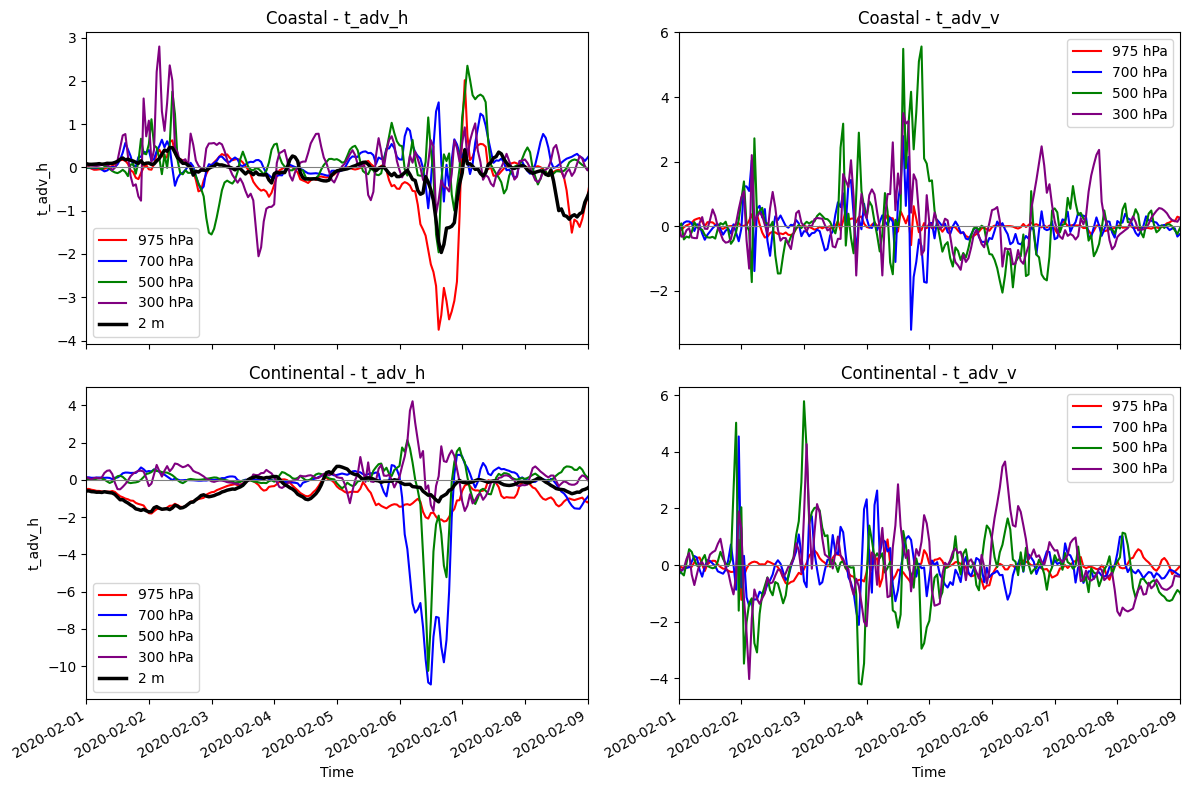

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Puntos
# =========================
lat1, lon1 = -63.5, -57.0   # Coastal
lat2, lon2 = -66.022, -63.877  # Continental

# =========================
# Datos
# =========================

# Coastal
ds_c = ds.sel(latitude=lat1, longitude=lon1, method='nearest')
da_c_h = ds_c['t_adv_h'].sel(pressure_level=[975, 700, 500, 300])
da_c_v = ds_c['t_adv_v'].sel(pressure_level=[975, 700, 500, 300])

ds_c_2m = ds_2m.sel(latitude=lat1, longitude=lon1, method='nearest')
da_c_2m = ds_c_2m['t_adv']

# Continental
ds_ct = ds.sel(latitude=lat2, longitude=lon2, method='nearest')
da_ct_h = ds_ct['t_adv_h'].sel(pressure_level=[975, 700, 500, 300])
da_ct_v = ds_ct['t_adv_v'].sel(pressure_level=[975, 700, 500, 300])

ds_ct_2m = ds_2m.sel(latitude=lat2, longitude=lon2, method='nearest')
da_ct_2m = ds_ct_2m['t_adv']

# =========================
# Figura 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

levels = [975, 700, 500, 300]

color_dict = {
    975: 'red',
    700: 'blue',
    500: 'green',
    300: 'purple'
}

# =========================
# Coastal - t_adv_h
# =========================
for p in levels:
    axes[0, 0].plot(
        da_c_h.valid_time,
        da_c_h.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

axes[0, 0].plot(
    da_c_2m.valid_time,
    da_c_2m,
    color='black',
    linewidth=2.5,
    label='2 m'
)

axes[0, 0].set_title('Coastal - t_adv_h')
axes[0, 0].set_ylabel('t_adv_h')
axes[0, 0].legend()

# =========================
# Coastal - t_adv_v
# =========================
for p in levels:
    axes[0, 1].plot(
        da_c_v.valid_time,
        da_c_v.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

axes[0, 1].set_title('Coastal - t_adv_v')
axes[0, 1].legend()

# =========================
# Continental - t_adv_h
# =========================
for p in levels:
    axes[1, 0].plot(
        da_ct_h.valid_time,
        da_ct_h.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

axes[1, 0].plot(
    da_ct_2m.valid_time,
    da_ct_2m,
    color='black',
    linewidth=2.5,
    label='2 m'
)

axes[1, 0].set_title('Continental - t_adv_h')
axes[1, 0].set_ylabel('t_adv_h')
axes[1, 0].set_xlabel('Time')
axes[1, 0].legend()

# =========================
# Continental - t_adv_v
# =========================
for p in levels:
    axes[1, 1].plot(
        da_ct_v.valid_time,
        da_ct_v.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

axes[1, 1].set_title('Continental - t_adv_v')
axes[1, 1].set_xlabel('Time')
axes[1, 1].legend()

# =========================
# Ajustes
# =========================
for ax in axes.flatten():
    ax.set_xlim(pd.to_datetime('2020-02-01'), pd.to_datetime('2020-02-09'))
    ax.axhline(0, color='gray', linewidth=0.8)

# Rotar fechas
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()

## Coastal and Continental for the PIs

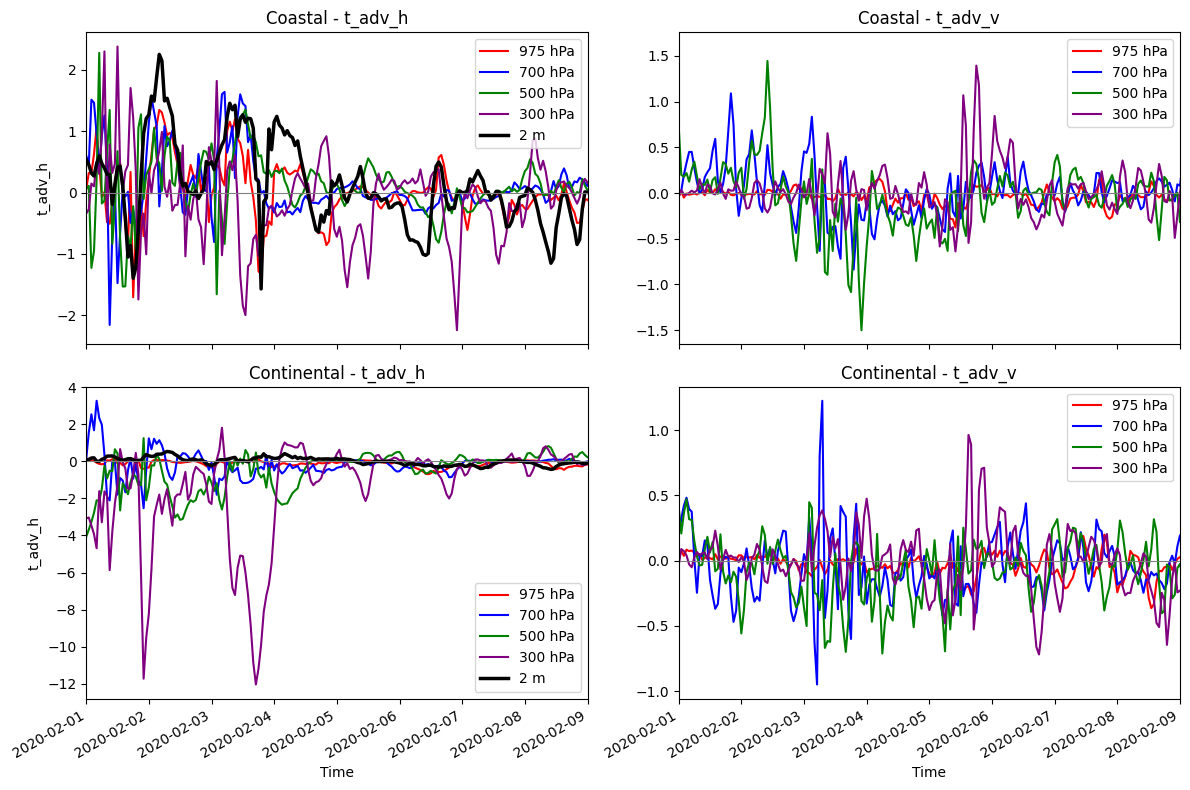

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Puntos
# =========================
lat1, lon1 = -48.29, -75.50   # Coastal
lat2, lon2 = -48.81, -73.51  # Continental

# =========================
# Datos
# =========================

# Coastal
ds_c = ds.sel(latitude=lat1, longitude=lon1, method='nearest')
da_c_h = ds_c['t_adv_h'].sel(pressure_level=[975, 700, 500, 300])
da_c_v = ds_c['t_adv_v'].sel(pressure_level=[975, 700, 500, 300])

ds_c_2m = ds_2m.sel(latitude=lat1, longitude=lon1, method='nearest')
da_c_2m = ds_c_2m['t_adv']

# Continental
ds_ct = ds.sel(latitude=lat2, longitude=lon2, method='nearest')
da_ct_h = ds_ct['t_adv_h'].sel(pressure_level=[975, 700, 500, 300])
da_ct_v = ds_ct['t_adv_v'].sel(pressure_level=[975, 700, 500, 300])

ds_ct_2m = ds_2m.sel(latitude=lat2, longitude=lon2, method='nearest')
da_ct_2m = ds_ct_2m['t_adv']

# =========================
# Figura 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

levels = [975, 700, 500, 300]

color_dict = {
    975: 'red',
    700: 'blue',
    500: 'green',
    300: 'purple'
}

# =========================
# Coastal - t_adv_h
# =========================
for p in levels:
    axes[0, 0].plot(
        da_c_h.valid_time,
        da_c_h.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

axes[0, 0].plot(
    da_c_2m.valid_time,
    da_c_2m,
    color='black',
    linewidth=2.5,
    label='2 m'
)

axes[0, 0].set_title('Coastal - t_adv_h')
axes[0, 0].set_ylabel('t_adv_h')
axes[0, 0].legend()

# =========================
# Coastal - t_adv_v
# =========================
for p in levels:
    axes[0, 1].plot(
        da_c_v.valid_time,
        da_c_v.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

axes[0, 1].set_title('Coastal - t_adv_v')
axes[0, 1].legend()

# =========================
# Continental - t_adv_h
# =========================
for p in levels:
    axes[1, 0].plot(
        da_ct_h.valid_time,
        da_ct_h.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

axes[1, 0].plot(
    da_ct_2m.valid_time,
    da_ct_2m,
    color='black',
    linewidth=2.5,
    label='2 m'
)

axes[1, 0].set_title('Continental - t_adv_h')
axes[1, 0].set_ylabel('t_adv_h')
axes[1, 0].set_xlabel('Time')
axes[1, 0].legend()

# =========================
# Continental - t_adv_v
# =========================
for p in levels:
    axes[1, 1].plot(
        da_ct_v.valid_time,
        da_ct_v.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

axes[1, 1].set_title('Continental - t_adv_v')
axes[1, 1].set_xlabel('Time')
axes[1, 1].legend()

# =========================
# Ajustes
# =========================
for ax in axes.flatten():
    ax.set_xlim(pd.to_datetime('2020-02-01'), pd.to_datetime('2020-02-09'))
    ax.axhline(0, color='gray', linewidth=0.8)

# Rotar fechas
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()

## Spatial at datetime 2020-02-07T12

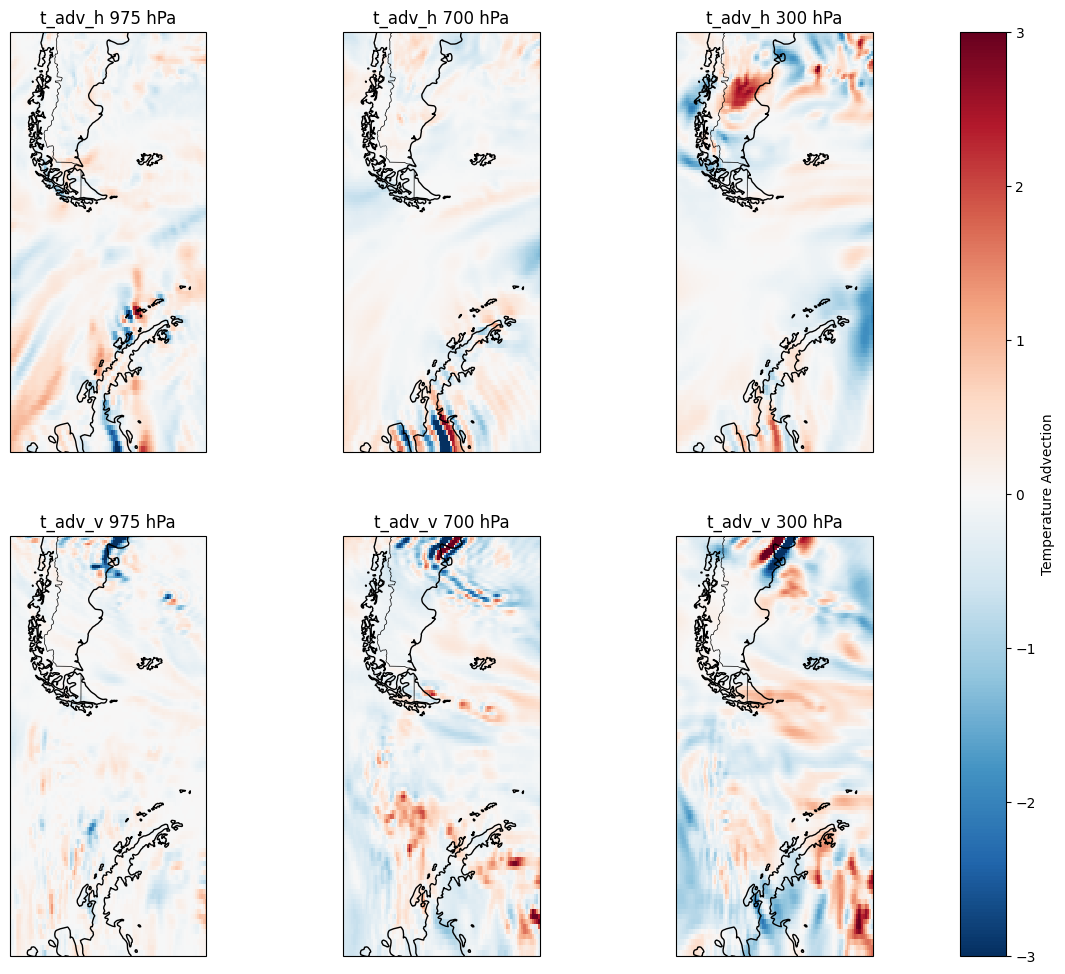

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

levels = [975, 700, 300]

# --- Select data ---
ds_sel = ds.sel(valid_time='2020-02-07T12')

da_h = ds_sel['t_adv_h'].sel(pressure_level=levels)
da_v = ds_sel['t_adv_v'].sel(pressure_level=levels)  # ⚠️ adjust name if needed

# --- Figure ---
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 12),
    subplot_kw={'projection': ccrs.Mercator()}
)

# --- Plot ---
for j, p in enumerate(levels):

    # --- Row 1: Horizontal ---
    ax = axes[0, j]
    m1 = da_h.sel(pressure_level=p).plot(
        ax=ax,
        x='longitude',
        y='latitude',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        vmin=-3, vmax=3,
        cmap='RdBu_r'
    )
    ax.set_title(f't_adv_h {p} hPa')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # --- Row 2: Vertical ---
    ax = axes[1, j]
    m2 = da_v.sel(pressure_level=p).plot(
        ax=ax,
        x='longitude',
        y='latitude',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        vmin=-3, vmax=3,
        cmap='RdBu_r'
    )
    ax.set_title(f't_adv_v {p} hPa')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# --- Row labels (cleaner than titles everywhere) ---
axes[0, 0].set_ylabel('Horizontal\nLatitude')
axes[1, 0].set_ylabel('Vertical\nLatitude')

# --- Shared colorbar ---
cbar = plt.colorbar(
    m1,
    ax=axes,
    orientation='vertical',
    fraction=0.05,
    pad=0.08
)
cbar.set_label('Temperature Advection')


## Mask filter

In [6]:
filename = '/home/lacrio/Documents/thermo_eq_test_lev/data/era5_t_uvw_20200201_20200209.nc'
ds_z = xr.open_dataset(filename)['z']

filename = '/home/lacrio/Documents/thermo_eq_test_lev/data/era5_t_uv_2m_20200201_20200209.nc'
ds_zsfc  = xr.open_dataset(filename)['z']


g = 9.80665

# Alturas
h = ds_z / g
h_sfc = ds_zsfc / g
h_sfc_expanded = h_sfc.expand_dims({'pressure_level': ds_z.pressure_level}, axis=1)

mask = h > h_sfc_expanded

ds_mask = ds.where(mask)

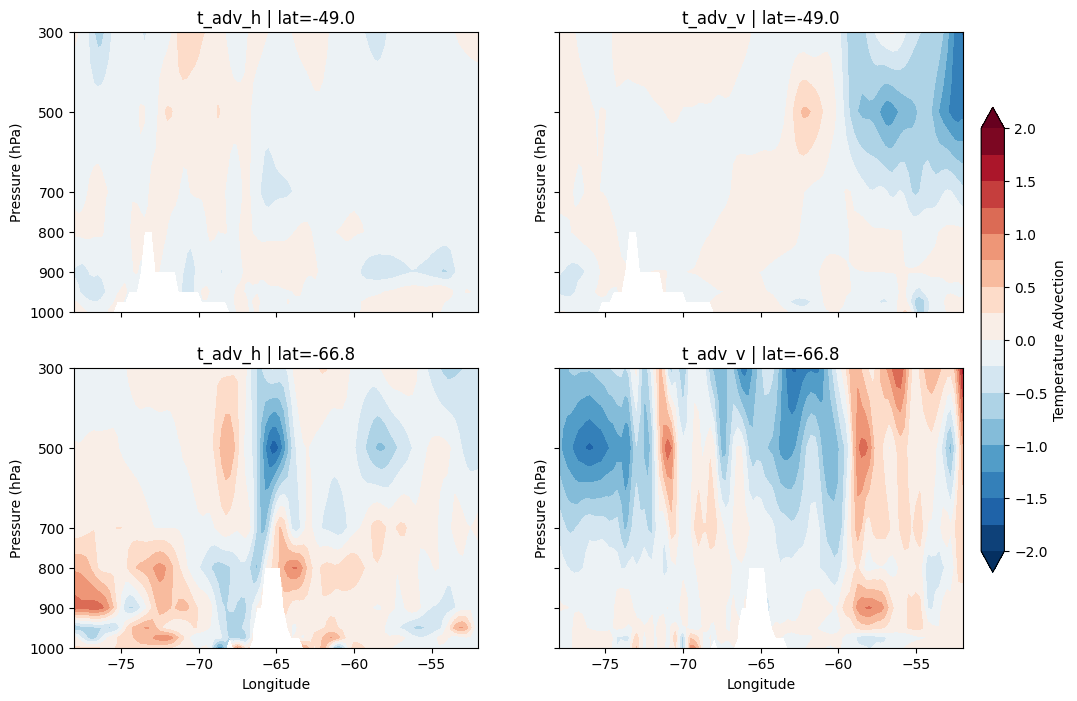

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# --- Selección de transectos ---
latitudes = [-49, -66.7]

ds_transects = ds_mask.sel(latitude=latitudes, method='nearest')

# Selección temporal
ds_plot = ds_transects.sel(valid_time='2020-02-07T13')

# Asegurar orden correcto global
ds_plot = ds_plot.sortby('pressure_level', ascending=False)

# --- Parámetros de color ---
vmin, vmax = -2., 2.1
levels = np.arange(vmin, vmax, 0.25)


# --- Figura ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

lats = ds_plot.latitude.values
vars_plot = ['t_adv_h', 't_adv_v']

# --- Loop principal ---
for i, lat in enumerate(lats):
    
    data = ds_plot.sel(latitude=lat).sortby('pressure_level', ascending=False)
    
    for j, var in enumerate(vars_plot):
        
        cf = axes[i, j].contourf(
            data.longitude,
            data.pressure_level,
            data[var],
            cmap='RdBu_r',
            levels=levels,
            extend='both'
        )
        
        axes[i, j].set_title(f'{var} | lat={lat:.1f}')
        
        # --- Eje vertical ---
        ax = axes[i, j]
        ax.set_ylim(1000, 300)
        ax.set_yticks([1000, 900, 800, 700, 500, 300])
        ax.set_ylabel('Pressure (hPa)')

# --- UNA sola colorbar global ---
cbar = fig.colorbar(
    cf,
    ax=axes.ravel(),
    orientation='vertical',
    extend='both',
    fraction=0.025,
    pad=0.02
)

cbar.set_label('Temperature Advection')

# --- Eje X ---
for ax in axes[-1, :]:
    ax.set_xlabel('Longitude')


In [8]:
mountain_threshold = 400  # metros
mountain_mask = h_sfc_expanded > mountain_threshold

pressure_mask = ds_z['pressure_level'] <= 975
pressure_mask = pressure_mask.broadcast_like(h)

mask_surface = h > h_sfc_expanded

import xarray as xr

mask_final = xr.where(
    mountain_mask,   # si es montaña
    mask_surface,    # usa topografía real
    pressure_mask    # si no → hasta 975 hPa
)

ds_mask = ds.where(mask_final)

# True donde hay datos válidos
valid = ds_mask['t_adv_h'].notnull()

# Índice del primer nivel válido (a lo largo de pressure_level)
idx = valid.argmax(dim='pressure_level')

ds_mask_sl = ds_mask.isel(pressure_level=idx)
ds_mask_sl

<xarray.Dataset> Size: 88MB
Dimensions:         (valid_time: 216, latitude: 121, longitude: 105)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 2kB 2020-02-01 ... 2020-02-09...
    pressure_level  (valid_time, latitude, longitude) float64 22MB 975.0 ... ...
  * latitude        (latitude) float64 968B -70.0 -69.75 -69.5 ... -40.25 -40.0
  * longitude       (longitude) float64 840B -78.0 -77.75 -77.5 ... -52.25 -52.0
    number          int64 8B 0
    expver          (valid_time) <U4 3kB '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    t_adv_h         (valid_time, latitude, longitude) float64 22MB -0.1778 .....
    tgradx          (valid_time, latitude, longitude) float32 11MB 0.05472 .....
    tgrady          (valid_time, latitude, longitude) float64 22MB -0.0602 .....
    t_adv_v         (valid_time, latitude, longitude) float32 11MB -0.1197 .....
Attributes:
    history:  Derived with advect_variable_cfd from /home/lacrio/Documents/th...

## Comp 975hPa and mask

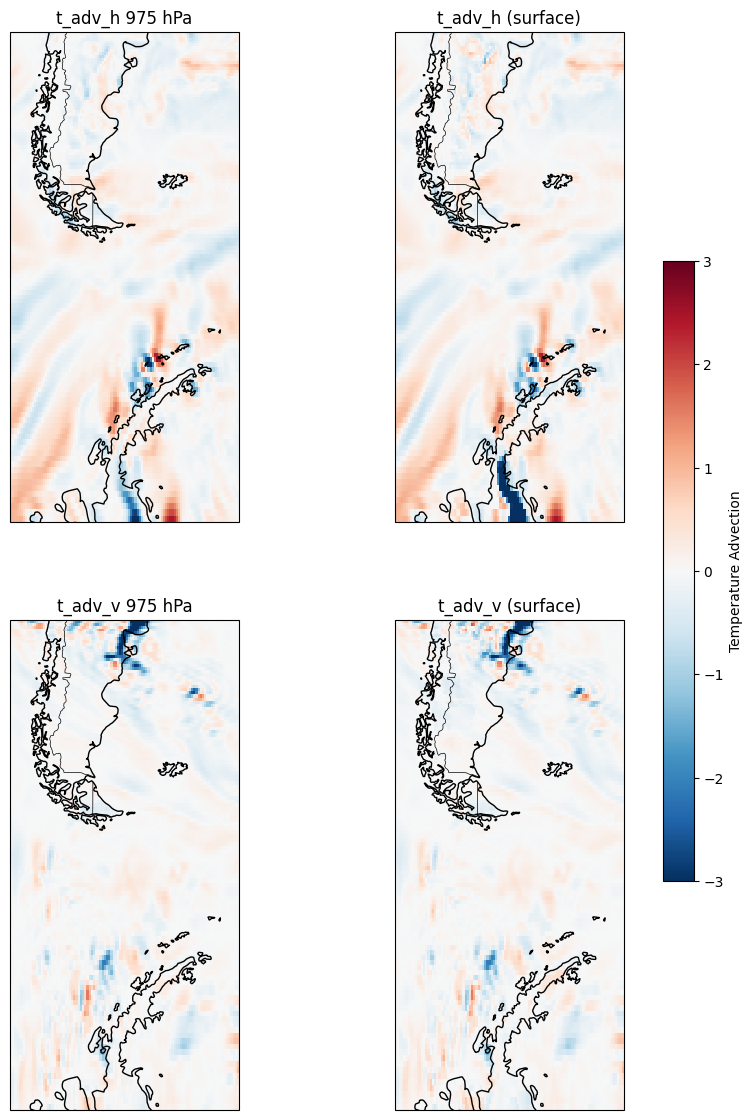

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Selección temporal ---
time_sel = '2020-02-07T13'

ds_pl = ds.sel(valid_time=time_sel)
ds_sl = ds_mask_sl.sel(valid_time=time_sel)

# Variables
da_h_pl = ds_pl['t_adv_h']
da_v_pl = ds_pl['t_adv_v']

da_h_sl = ds_sl['t_adv_h']
da_v_sl = ds_sl['t_adv_v']

# --- Figura 2x2 ---
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 14),
    subplot_kw={'projection': ccrs.Mercator()}
)

vmin, vmax = -3, 3
cmap = 'RdBu_r'

# =========================
# Columna 1 → 975 hPa
# =========================

# --- t_adv_h ---
ax = axes[0, 0]
m = da_h_pl.sel(pressure_level=975).plot(
    ax=ax,
    x='longitude',
    y='latitude',
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    vmin=vmin, vmax=vmax,
    cmap=cmap
)
ax.set_title('t_adv_h 975 hPa')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# --- t_adv_v ---
ax = axes[1, 0]
da_v_pl.sel(pressure_level=975).plot(
    ax=ax,
    x='longitude',
    y='latitude',
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    vmin=vmin, vmax=vmax,
    cmap=cmap
)
ax.set_title('t_adv_v 975 hPa')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# =========================
# Columna 2 → Single Level
# =========================

# --- t_adv_h ---
ax = axes[0, 1]
da_h_sl.plot(
    ax=ax,
    x='longitude',
    y='latitude',
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    vmin=vmin, vmax=vmax,
    cmap=cmap
)
ax.set_title('t_adv_h (surface)')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# --- t_adv_v ---
ax = axes[1, 1]
da_v_sl.plot(
    ax=ax,
    x='longitude',
    y='latitude',
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    vmin=vmin, vmax=vmax,
    cmap=cmap
)
ax.set_title('t_adv_v (surface)')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)


# --- Colorbar única ---
cbar = plt.colorbar(
    m,
    ax=axes,
    orientation='vertical',
    fraction=0.04,
    pad=0.05
)
cbar.set_label('Temperature Advection')


## Just continetal over APIS and PIs

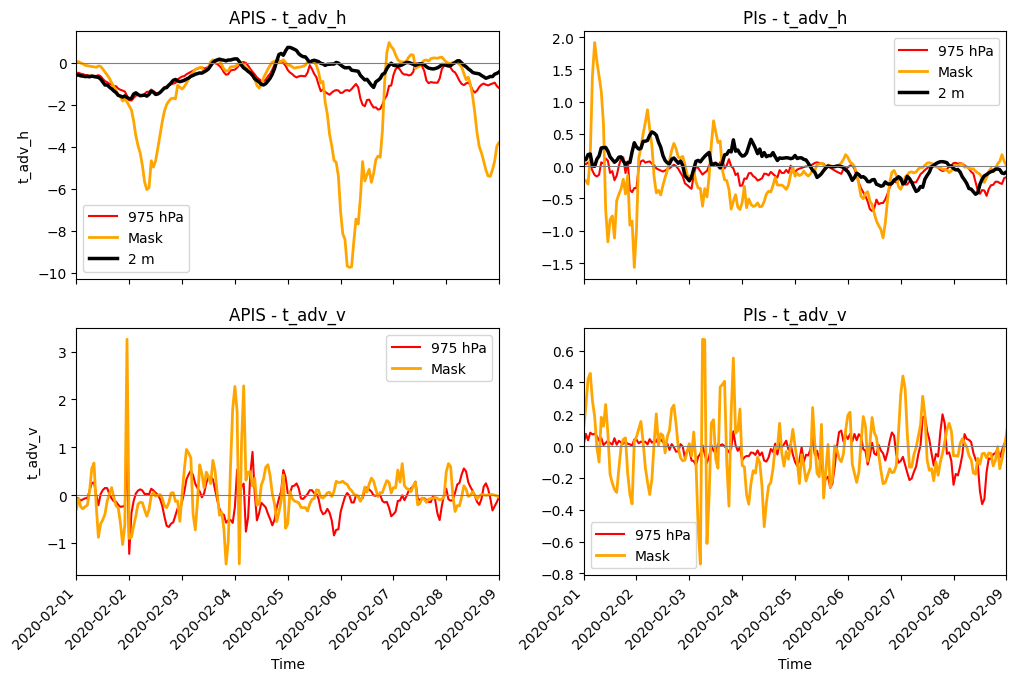

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Coordenadas
# =========================

# APIS (continental)
lat1, lon1 = -66.022, -63.877

# PIs (continental)
lat2, lon2 = -48.81, -73.51

# =========================
# Selección de datos
# =========================

# --- APIS ---
ds_apis = ds.sel(latitude=lat1, longitude=lon1, method='nearest')
mask_apis = ds_mask_sl.sel(latitude=lat1, longitude=lon1, method='nearest')
ds_apis_2m = ds_2m.sel(latitude=lat1, longitude=lon1, method='nearest')

# Horizontal
apis_975_h = ds_apis['t_adv_h'].sel(pressure_level=975)
apis_mask_h = mask_apis['t_adv_h']
apis_2m = ds_apis_2m['t_adv']

# Vertical
apis_975_v = ds_apis['t_adv_v'].sel(pressure_level=975)
apis_mask_v = mask_apis['t_adv_v']

# --- PIs ---
ds_pis = ds.sel(latitude=lat2, longitude=lon2, method='nearest')
mask_pis = ds_mask_sl.sel(latitude=lat2, longitude=lon2, method='nearest')
ds_pis_2m = ds_2m.sel(latitude=lat2, longitude=lon2, method='nearest')

# Horizontal
pis_975_h = ds_pis['t_adv_h'].sel(pressure_level=975)
pis_mask_h = mask_pis['t_adv_h']
pis_2m = ds_pis_2m['t_adv']

# Vertical
pis_975_v = ds_pis['t_adv_v'].sel(pressure_level=975)
pis_mask_v = mask_pis['t_adv_v']

# =========================
# Figura 2x2
# =========================

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# =========================
# APIS
# =========================

# --- Horizontal ---
axes[0, 0].plot(apis_975_h.valid_time, apis_975_h, color='red', label='975 hPa')
axes[0, 0].plot(apis_mask_h.valid_time, apis_mask_h, color='orange', linewidth=2, label='Mask')
axes[0, 0].plot(apis_2m.valid_time, apis_2m, color='black', linewidth=2.5, label='2 m')

axes[0, 0].set_title('APIS - t_adv_h')
axes[0, 0].set_ylabel('t_adv_h')
axes[0, 0].legend()

# --- Vertical ---
axes[1, 0].plot(apis_975_v.valid_time, apis_975_v, color='red', label='975 hPa')
axes[1, 0].plot(apis_mask_v.valid_time, apis_mask_v, color='orange', linewidth=2, label='Mask')

axes[1, 0].set_title('APIS - t_adv_v')
axes[1, 0].set_ylabel('t_adv_v')
axes[1, 0].set_xlabel('Time')
axes[1, 0].legend()

# =========================
# PIs
# =========================

# --- Horizontal ---
axes[0, 1].plot(pis_975_h.valid_time, pis_975_h, color='red', label='975 hPa')
axes[0, 1].plot(pis_mask_h.valid_time, pis_mask_h, color='orange', linewidth=2, label='Mask')
axes[0, 1].plot(pis_2m.valid_time, pis_2m, color='black', linewidth=2.5, label='2 m')

axes[0, 1].set_title('PIs - t_adv_h')
axes[0, 1].legend()

# --- Vertical ---
axes[1, 1].plot(pis_975_v.valid_time, pis_975_v, color='red', label='975 hPa')
axes[1, 1].plot(pis_mask_v.valid_time, pis_mask_v, color='orange', linewidth=2, label='Mask')

axes[1, 1].set_title('PIs - t_adv_v')
axes[1, 1].set_xlabel('Time')
axes[1, 1].legend()

# =========================
# Ajustes
# =========================

for ax in axes.flatten():
    ax.set_xlim(pd.to_datetime('2020-02-01'), pd.to_datetime('2020-02-09'))
    ax.axhline(0, color='gray', linewidth=0.8)

fig.autofmt_xdate(rotation=45)
#plt.tight_layout()
#plt.show()

## Test level model 137 and 136

In [ ]:
filename = '/home/lacrio/DATA/term_cal/era5_tuvwz_20200205_20200208.nc'
ds = xr.open_dataset(filename)

T137 = ds['t'].sel(model_level=137)
T136 = ds['t'].sel(model_level=136)

Z137 = 10
Z136 = 30.96
dTdZ = (T136-T137) / (Z136-Z137) 


rho = 1.2  # aproximación
w137_ms =  ds['w'].sel(model_level=137) / (rho * 9.81)

adv_vert = - (w137_ms * dTdZ) * 3600 

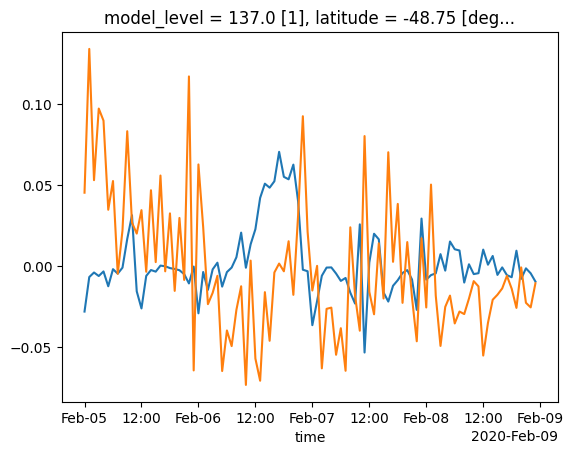

In [43]:
# APIS (continental)
lat1, lon1 = -66.022, -63.877

# PIs (continental)
lat2, lon2 = -48.81, -73.51

# =========================
# Selección de datos
# =========================

# --- APIS ---
ds_apis = adv_vert.sel(latitude=lat1, longitude=lon1, method='nearest').plot()

# --- APIS ---
ds_pis = adv_vert.sel(latitude=lat2, longitude=lon2, method='nearest').plot()
